In [1]:
import config
import tensorflow.keras as keras
import tensorflow as tf
from CustomLossFunction import DiceLoss
from Generator import DataGenerator
import Generator
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ModelBuilding import CreateModel
os.getcwd()

'd:\\WorkAttachment\\codes\\code6'

In [2]:
# model = keras.models.load_model(os.path.sep.join(["output","detector20201216-181001.h5"]), compile=False)   
model = CreateModel()
# keras.models.load_model(os.path.sep.join(["output","models","bests", "model.01-6.70.h5"]), compile=True, custom_objects={'DiceLoss':DiceLoss})

Creating model
Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 512, 512, 3) 0                                            
__________________________________________________________________________________________________
block1_conv1 (Conv2D)           (None, 512, 512, 64) 1792        input_1[0][0]                    
__________________________________________________________________________________________________
block1_conv2 (Conv2D)           (None, 512, 512, 64) 36928       block1_conv1[0][0]               
__________________________________________________________________________________________________
block1_pool (MaxPooling2D)      (None, 256, 256, 64) 0           block1_conv2[0][0]               
________________________________________________________________________

In [3]:
losses = {
        "class_label": tf.keras.losses.categorical_crossentropy,
        "bounding_box": DiceLoss,
    }
model.load_weights(os.path.sep.join(["output","models","bests", "model.02--13.46.h5"]))
model.compile(loss=losses)

In [4]:
datagen = DataGenerator(['kidneyHU.png', 'lungHU.png'], '.', to_fit=False, csvpath=config.ANNOTS_PATH)

In [5]:
imgarrs = [Generator.ImagePreprocessing(i, (512,512)) for i in ['kidneyHU.png', 'lungHU.png']]
imgarrs = np.array(imgarrs)
print(imgarrs.shape)

(2, 512, 512, 3)


In [6]:
output = model(imgarrs, training=False)

In [7]:
for i in range(len(output)):
    print(output[i].shape)

(2, 8)
(2, 512, 512, 1)


In [8]:
for i in range(2):
    leison_types = output[0][i]
    aimg = output[1][i]
#     break
    num = np.argmax(leison_types)
    
    print(num, config.NUM_TYPE_MAPPING[str(num+1)])

0 bone
0 bone


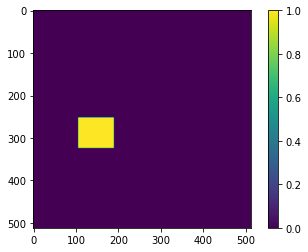

In [9]:
# mask = generator.ImagePreprocessing('kidneyHU.png', (512,512))
mask = datagen._generate_y(['000010_01_01_084.png'])['bounding_box']
# mask = np.delete(mask, np.s_[1:], axis=-1).reshape(512,512)
# print(mask)
original = plt.imshow(mask.reshape(512,512))
plt.colorbar()

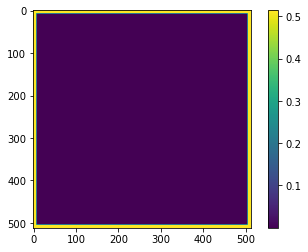

In [25]:
numpymask = np.array(output[1][0]).squeeze()
# plt.hist(numpymask.ravel(), bins=256, range=(0.0, 1.0), fc='k', ec='k')
imgplot = plt.imshow(numpymask)
plt.colorbar()

(512, 512)


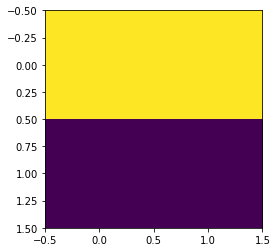

In [11]:
numpymask = np.array(np.array(output[1][0]) == 0, dtype=int)
numpymask.resize(512,512)
print(numpymask.shape)
# plt.imshow(numpymask)
plt.imshow([[1,1], [0,0]])

In [12]:
contours,_ = cv2.findContours(numpymask.copy(), 1, 1) # not copying here will throw an error
rect = cv2.minAreaRect(contours[0]) # basically you can feed this rect into your classifier
(x,y),(w,h), a = rect # a - angle

box = cv2.boxPoints(rect)
box = np.int0(box) #turn into ints
rect2 = cv2.drawContours(img.copy(),[box],0,(0,0,255),10)

plt.imshow(rect2)
plt.show()

error: OpenCV(4.4.0) C:\Users\appveyor\AppData\Local\Temp\1\pip-req-build-52oirelq\opencv\modules\imgproc\src\contours.cpp:197: error: (-210:Unsupported format or combination of formats) [Start]FindContours supports only CV_8UC1 images when mode != CV_RETR_FLOODFILL otherwise supports CV_32SC1 images only in function 'cvStartFindContours_Impl'
